## Testing the Gadget for the $^{20}\text{O}$ in the Quasiparticle Picture

### Imports

In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
from src.interaction_utils import EffectiveInteractionOptimizer
from ManyBodyQutip.qutip_class import SpinOperator, SpinHamiltonian
import qutip as qt
from src.utils import computational_basis
from qutip import fidelity
from NSMFermions.hamiltonian_utils import FermiHubbardHamiltonian
from NSMFermions.nuclear_physics_utils import (
    get_twobody_nuclearshell_model,
    SingleParticleState,
)
import numpy as np
import torch
from typing import Dict
import scipy
from NSMFermions.qml_models import AdaptVQEFermiHubbard
from NSMFermions.qml_utils.train import Fit
from NSMFermions.qml_utils.utils import configuration
from scipy.sparse.linalg import eigsh, expm_multiply
from tqdm import trange
import matplotlib.pyplot as plt
from NSMFermions.utils_quasiparticle_approximation import (
    QuasiParticlesConverter,
    HardcoreBosonsBasis,
    QuasiParticlesConverterOnlynnpp,
)
from src.utils import generate_particleconservation_basis, array_to_qutip

/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


### Load the coupling of the Quasiparticle Hamiltonian

We upload the $g^{(1)}_{AB}$ couplings from the numpy dictionary, we also fix the number of Qubit for the system that we are considering. Since the $^{6}\text{Be}$ involves only one active quasiparticle proton, we don't need any two-body interaction

In [2]:
data_onebody = np.load("data/matrix_elements_h_eff_2body/one_body_nn_sd.npz")
keys = data_onebody["keys"]
values = data_onebody["values"]
n_qubits = 6

g_onebody = {}
diagonal_elements = np.zeros(n_qubits)
g_matrix = np.zeros((n_qubits, n_qubits))
for a, key in enumerate(keys):
    i, j = key
    g_onebody[(i, j)] = values[a]
    if i != j:
        g_matrix[i, j] = values[a]
    if i == j:
        diagonal_elements[i] = values[a]

data_twobody = np.load("data/matrix_elements_h_eff_2body/twobody_nn_sd.npz")
keys = data_twobody["keys"]
values = data_twobody["values"]
g_twobody = {}
for a, key in enumerate(keys):
    i, j, k, l = key
    g_twobody[(i, j)] = values[a]
    print(i, j, k, l, values[a])
    if i != k and j != l:
        print(i, j, k, l)
        print(values[a])

# get the computational basis of the space
basis = computational_basis(n_qubits)

0 1 0 1 -1.9616000000000007
0 2 0 2 -1.394600000000004
0 3 0 3 0.02873333333332795
0 4 0 4 -2.203928571428574
0 5 0 5 0.058295238095237956
1 2 1 2 -2.3017999999999965
1 3 1 3 0.0287333333333315
1 4 1 4 -0.8465942857142865
1 5 1 5 -1.2990390476190479
2 3 2 3 0.028733333333335054
2 4 2 4 -0.16792714285714272
2 5 2 5 -1.9777061904761917
3 4 3 4 0.015199999999999214
3 5 3 5 0.015199999999999214
4 5 4 5 -0.3896000000000015


#### Study the Quasiparticle Hamiltonian with the Hardcore Boson Basis

In [3]:
nparticles_a = 2
nparticles_b = 0

particle_conserved_basis = generate_particleconservation_basis(
    size_a=n_qubits, size_b=0, nparticles_a=nparticles_a, nparticles_b=nparticles_b
)


# initialize the class in the number sector of the quasiparticle space (see NSMFermion library)
HBB = HardcoreBosonsBasis(basis=particle_conserved_basis)
quasiparticle_hamiltonian_particle_conserved = 0.0
for key, value in g_onebody.items():
    idx_a, idx_b = key
    if idx_a != idx_b:
        quasiparticle_hamiltonian_particle_conserved += value * HBB.adag_a_matrix(
            idx_a, idx_b
        )
    else:
        quasiparticle_hamiltonian_particle_conserved += value * HBB.adag_a_matrix(
            idx_a, idx_b
        )

for key, value in g_twobody.items():
    idx_a, idx_b = key
    quasiparticle_hamiltonian_particle_conserved += value * HBB.adag_adag_a_a_matrix(
        idx_a, idx_b, idx_a, idx_b
    )

value, eigenstates_particle_conserved = np.linalg.eigh(
    quasiparticle_hamiltonian_particle_conserved.todense()
)

print(value)

[-23.42493918 -20.52242071 -19.67274996 -18.26654306 -16.81194491
 -15.9140891   -9.40487689  -8.37403332  -7.06474067  -6.85550939
  -5.44478182  -4.71386903  -4.44391355  -3.22456721   6.87857879]


/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/numba/typed/typeddict.py:39: NumbaTypeSafetyWarning: unsafe cast from int64 to uint64. Precision may be lost.
  return d[key]


#### Write the NSM Quasiparticle Hamiltonian in Qutip, using the whole Hilbert space

In [4]:
hamiltonian_xy = 0.0
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        hamiltonian_xy += SpinOperator(
            [("x", i, "x", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=n_qubits,
            verbose=1,
        ).qutip_op
        hamiltonian_xy += SpinOperator(
            [("y", i, "y", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=n_qubits,
            verbose=1,
        ).qutip_op
hamiltonian_z = 0.0
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        hamiltonian_z += SpinOperator(
            [("qz", i, "qz", j)], coupling=[g_twobody[(i, j)]], size=n_qubits, verbose=1
        ).qutip_op

for i in range(n_qubits):
    hamiltonian_z += SpinOperator(
        [("qz", i)], coupling=[diagonal_elements[i]], size=n_qubits, verbose=1
    ).qutip_op

nsm_quasiparticle_hamiltonian = hamiltonian_z + hamiltonian_xy

Diagonalization using the Qutip routine

In [5]:
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

Plot the spectrum

In [6]:
print(eigenvalues_nsm)
# the gs in the number sector is different from the vacuum.
# In this way we select the gs of the number sector
gs_idx = np.argmin(np.abs(eigenvalues_nsm - value[0]))
print(gs_idx, eigenvalues_nsm[gs_idx])

[-42.71298534 -42.12274301 -41.3464     -40.18317535 -34.67433578
 -34.64777143 -33.43743989 -32.67421028 -29.79011229 -29.2564119
 -28.53176656 -28.41848438 -27.57197083 -27.35991208 -26.73932477
 -26.59414081 -25.98977465 -25.63385455 -25.3014     -25.10101513
 -23.42493918 -21.9654357  -20.89683668 -20.52242071 -19.67274996
 -19.28303066 -19.23514473 -19.21059676 -18.26654306 -17.95296014
 -17.88544834 -17.31381824 -17.26410663 -16.81194491 -16.50726894
 -15.9140891  -15.85882103 -14.75666784 -14.25484575 -13.26065145
 -13.21695938 -12.63396231 -12.54362933 -11.93178825 -11.78332373
  -9.40487689  -8.9655495   -8.37403332  -8.0583      -7.33926256
  -7.06474067  -6.85550939  -5.90728335  -5.44478182  -4.71386903
  -4.52953339  -4.44391355  -3.76845229  -3.22456721  -0.84349427
   0.           3.07695081   4.2394495    6.87857879]
20 -23.424939176438862


Now, we get the spectrum of this Hamiltonian

### Puzzle of the Effective interaction

Following our notes on the gadget, we need to verify if we can reproduce the interaction by using the transverse field per site $d_i$. Since the relevant term in the effective Hamiltonian comes out as $H_{\text{int,eff}}=-\frac{1}{\gamma}\sum_{A \neq B} d_A d_B (X_A X_B +Y_A Y_B)$. We need to figure out if we can solve the condition $g_{AB}=-d_A d_B$. To do so, we treat it as an optimization problem. 

Optimal drive parameters: [-0.90513022  1.02535363 -0.96153052 -0.79417758 -1.10508836  1.13502171]
Optimized effective interaction matrix:
 [[ 0.00000000e+00  2.38278549e-01 -4.64010325e-01  1.81947765e-01
   9.31196813e-01  4.25607483e-01]
 [ 2.38278549e-01  0.00000000e+00  1.26008801e-01 -8.64690299e-02
  -5.12895946e-04  2.35762766e-01]
 [-4.64010325e-01  1.26008801e-01  0.00000000e+00  1.37155912e-01
  -3.27870144e-01 -7.07116594e-01]
 [ 1.81947765e-01 -8.64690299e-02  1.37155912e-01  0.00000000e+00
  -1.59923014e-01  1.83695412e-01]
 [ 9.31196813e-01 -5.12895946e-04 -3.27870144e-01 -1.59923014e-01
   0.00000000e+00  3.53399279e-01]
 [ 4.25607483e-01  2.35762766e-01 -7.07116594e-01  1.83695412e-01
   3.53399279e-01  0.00000000e+00]]


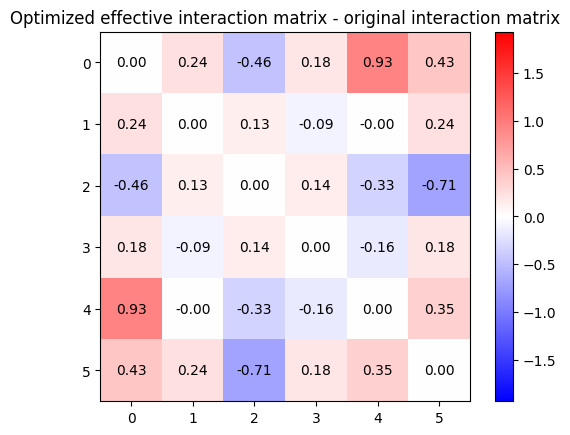

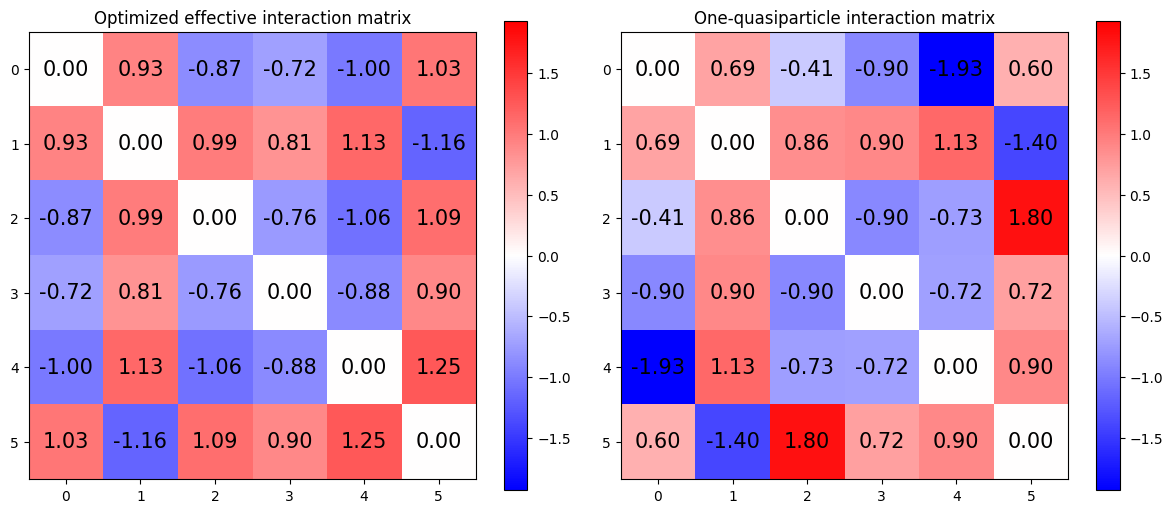

In [7]:
OptimalFieldBe6 = EffectiveInteractionOptimizer(
    nqubit=n_qubits, n_restarts=100, scale=2.0, ftol=1e-15, gtol=1e-10
)

d_opt, result = OptimalFieldBe6.optimize_rank1(g_matrix)
print("Optimal drive parameters:", d_opt)
print(
    "Optimized effective interaction matrix:\n",
    OptimalFieldBe6.reconstructed(d_opt) - g_matrix,
)
plt.imshow(
    OptimalFieldBe6.reconstructed(d_opt) - g_matrix,
    cmap="bwr",
    vmin=-np.max(np.abs(g_matrix)),
    vmax=np.max(np.abs(g_matrix)),
)
for i in range(n_qubits):
    for j in range(n_qubits):
        plt.text(
            j,
            i,
            f"{OptimalFieldBe6.reconstructed(d_opt)[i,j]-g_matrix[i,j]:.2f}",
            ha="center",
            va="center",
            color="black",
        )
plt.colorbar()
plt.title("Optimized effective interaction matrix - original interaction matrix")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

vmax = np.max(np.abs(g_matrix))
matrices = [OptimalFieldBe6.reconstructed(d_opt), g_matrix]
titles = [
    "Optimized effective interaction matrix",
    "One-quasiparticle interaction matrix",
]

for ax, mat, title in zip(axes, matrices, titles):
    im = ax.imshow(mat, cmap="bwr", vmin=-vmax, vmax=vmax)
    for i in range(n_qubits):
        for j in range(n_qubits):
            ax.text(
                j,
                i,
                f"{mat[i,j]:.2f}",
                ha="center",
                va="center",
                color="black",
                fontsize=15,
            )
    plt.colorbar(im, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Write the Diagonal part of the Ising Hamiltonian

Now, we have to write the full ising Hamiltonian that describes the constrain subspace, where our effective Hamiltonian acts, and then see how the spectrum behaves

#### Define the hamiltonian $H_z$ out of the couplings and constrains

In [8]:
# get the total particle constrain
gamma = 200
ntot = 2  # here ntot is different from 1
# we define the effective longitudianl field that contributes to the NSM quasiparticle hamiltonian of Be 6
effective_longitudinal_field = (diagonal_elements + 0.5 * (d_opt**2).sum() / ntot) / (
    gamma
)


# lets start with the Z_A Z_B of the constrain
hamiltonian_zz = 0.0
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        hamiltonian_zz += SpinOperator(
            [("qz", i, "qz", j)],
            coupling=[2 * gamma + g_twobody[(i, j)] / gamma],
            size=n_qubits,
            verbose=1,
        ).qutip_op

# then the linear terms
hamiltonian_z = 0.0
for i in range(n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    hamiltonian_z += SpinOperator(
        [("qz", i)],
        coupling=[effective_longitudinal_field[i] + gamma * (1 - 2 * ntot)],
        size=n_qubits,
        verbose=1,
    ).qutip_op

# finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
identity_qubit_space = qt.tensor([qt.qeye(2)] * n_qubits)

longitudinal_hamiltonian = (
    hamiltonian_zz + hamiltonian_z + gamma * (ntot**2) * identity_qubit_space
)

Visualize the spectrum on the screen.

In [9]:
for i, b in enumerate(basis):
    print(i, b, longitudinal_hamiltonian.diag()[i])
    print("\n")

0 [0 0 0 0 0 0] 800.0


1 [0 0 0 0 0 1] 200.02354470536488


2 [0 0 0 0 1 0] 200.02354470536488


3 [0 0 0 0 1 1] 0.04514141072968414


4 [0 0 0 1 0 0] 199.9668837053648


5 [0 0 0 1 0 1] -0.00949558927027283


6 [0 0 0 1 1 0] -0.00949558927027283


7 [0 0 0 1 1 1] 200.01217711609456


8 [0 0 1 0 0 0] 199.9616942053649


9 [0 0 1 0 0 1] -0.024649620222589874


10 [0 0 1 0 1 0] -0.015600724984551562


11 [0 0 1 0 1 1] 199.99610744942788


12 [0 0 1 1 0 0] -0.07127842260365469


13 [0 0 1 1 0 1] 199.9424537518089


14 [0 0 1 1 1 0] 199.95150264704694


15 [0 0 1 1 1 1] 799.9632868214599


16 [0 1 0 0 0 0] 199.9631117053649


17 [0 1 0 0 0 1] -0.019838784508465324


18 [0 1 0 0 1 0] -0.017576560698898902


19 [0 1 0 0 1 1] 199.99752494942777


20 [0 1 0 1 0 0] -0.06986092260376608


21 [0 1 0 1 0 1] 199.94726458752302


22 [0 1 0 1 1 0] 199.9495268113326


23 [0 1 0 1 1 1] 799.9647043214595


24 [0 1 1 0 0 0] -0.08670308927003134


25 [0 1 1 0 0 1] 199.92045788990436


26 [0 1 1 0 1 0] 19

### Part of the second step is to introduce the transverse field term

In [10]:
# the transverse field
transverse_hamiltonian = 0.0
for i in range(n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    transverse_hamiltonian += SpinOperator(
        [("x", i)], coupling=[d_opt[i] / np.sqrt(2)], size=n_qubits, verbose=1
    ).qutip_op

#### Compute the spectrum of the full Hamiltonian

Once that we compute the spectrum, we expect that our ground state lies in the subspace near the $E_0=0$ region, Let's see what we get

In [11]:
total_hamiltonian = longitudinal_hamiltonian + transverse_hamiltonian
eigenvalues_total_hamiltonian, eigenstates_total_hamiltonian = (
    total_hamiltonian.eigenstates()
)

#### Check the structure of the effective Hamiltonian to control the longitudinal couplings $g_{AA}$

In [12]:
print(eigenvalues_total_hamiltonian[0] * gamma)

print(
    "fidelity between the gadget groundstate and the NSM groundstate:",
    fidelity(eigenstates_total_hamiltonian[0], eigenstates_nsm[gs_idx]),
    " at gamma=",
    gamma,
)

-23.563937285367746
fidelity between the gadget groundstate and the NSM groundstate: 0.9979965466231887  at gamma= 200


/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/transforms.py:758: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)
/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/transforms.py:758: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)


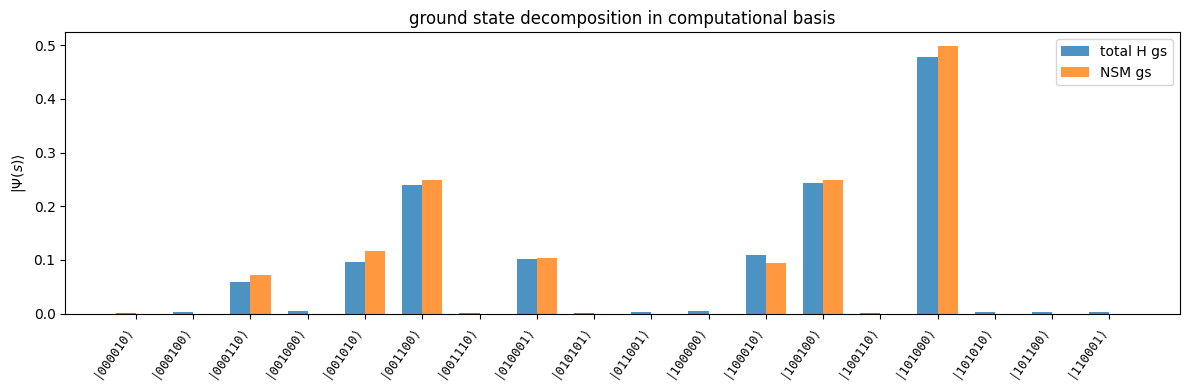

In [13]:
import matplotlib.pyplot as plt
import numpy as np


def plot_state_comparison(
    state1, state2, basis, label1="total H gs", label2="NSM gs", threshold=1e-3
):
    amps1 = state1.full().flatten()
    amps2 = state2.full().flatten()

    probs1 = amps1
    probs2 = amps2

    # filter: keep basis states where either state has weight above threshold
    mask = (probs1 > threshold) | (probs2 > threshold)
    bit_labels = ["|" + "".join(str(b) for b in bits) + "⟩" for bits in basis[mask]]
    p1 = probs1[mask]
    p2 = probs2[mask]

    x = np.arange(len(bit_labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(x - width / 2, p1, width, label=label1, alpha=0.8)
    ax.bar(x + width / 2, p2, width, label=label2, alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(
        bit_labels, rotation=55, ha="right", fontsize=9, fontfamily="monospace"
    )
    ax.set_ylabel(r"$|\Psi(s)\rangle $")
    ax.legend()
    ax.set_title("ground state decomposition in computational basis")
    plt.tight_layout()
    plt.show()


plot_state_comparison(eigenstates_total_hamiltonian[0], eigenstates_nsm[gs_idx], basis)

#### Adiabatic State Preparation

We divide the initialization of the total hamiltonian, since the driver is just the 0-th component of the Z hamiltonian. We just need to tune the initialization of the other components

In [77]:
# get the total particle constrain
gamma = 10
# get the total particle constrain
ntot = 2
# we define the effective longitudianl field that contributes to the NSM quasiparticle hamiltonian of Be 6
effective_longitudinal_field = (diagonal_elements + 0.5 * (d_opt**2).sum() / ntot) / (
    gamma
)


# lets start with the Z_A Z_B of the constrain
hamiltonian_zz = 0.0
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        hamiltonian_zz += SpinOperator(
            [("qz", i, "qz", j)], coupling=[2 * gamma], size=n_qubits, verbose=1
        ).qutip_op

# then the linear terms
hamiltonian_z = 0.0
for i in range(n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    hamiltonian_z += SpinOperator(
        [("qz", i)],
        coupling=[effective_longitudinal_field[i] + gamma * (1 - 2 * ntot)],
        size=n_qubits,
        verbose=1,
    ).qutip_op

# finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
identity_qubit_space = qt.tensor([qt.qeye(2)] * n_qubits)

total_hamiltonian = (
    hamiltonian_zz + hamiltonian_z + gamma * (ntot**2) * identity_qubit_space
)
# the transverse field is part of the variable hamiltonian
for i in range(n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    total_hamiltonian += SpinOperator(
        [("x", i)], coupling=[d_opt[i] / (np.sqrt(2))], size=n_qubits, verbose=1
    ).qutip_op

Then the driver Hamiltonian

In [78]:
# we define the effective longitudianl field that contributes to the driver hamiltonian hamiltonian of Be 6
external_field = np.zeros(diagonal_elements.shape[0])
external_field[0] = diagonal_elements[0]
external_field[1] = diagonal_elements[1]
print(external_field)

effective_longitudinal_field = (external_field) / (gamma)


# lets start with the Z_A Z_B of the constrain
hamiltonian_zz = 0.0
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        hamiltonian_zz += SpinOperator(
            [("qz", i, "qz", j)],
            coupling=[2 * gamma + g_twobody[(i, j)] / gamma],
            size=n_qubits,
            verbose=1,
        ).qutip_op

# then the linear terms
hamiltonian_z = 0.0
for i in range(n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    hamiltonian_z += SpinOperator(
        [("qz", i)],
        coupling=[effective_longitudinal_field[i] + gamma * (1 - 2 * ntot)],
        size=n_qubits,
        verbose=1,
    ).qutip_op

# finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
identity_qubit_space = qt.tensor([qt.qeye(2)] * n_qubits)

driver_hamiltonian = (
    hamiltonian_zz + hamiltonian_z + gamma * (ntot**2) * identity_qubit_space
)

print(np.argsort(driver_hamiltonian.full().diagonal()))
idx_init = np.argsort(driver_hamiltonian.full().diagonal())[0]
print(basis[idx_init], driver_hamiltonian.full().diagonal()[idx_init])

[-9.3151 -8.8615  0.      0.      0.      0.    ]
[48 34 24 40 17 18 36 33 20  9  3 10  6  5 12 56 50 49 52 25 42 41 26 35
 38 19 28 44 21 22 32 37 16 11 13  7 14  4  2  1  8 58 57 51 60 54 53 27
 43 29 46 45 30 39 23 15  0 59 62 61 55 31 47 63]
[1 1 0 0 0 0] (-2.0138200000000026+0j)


Then we get the state preparation, initializing the state and evolving the interpolate hamiltonian

Time evolution

In [79]:
#### Initialize the state and convert the hamiltonians
import scipy.sparse as sp
from scipy.sparse.linalg import expm_multiply

total_hamiltonian_sparse = total_hamiltonian.data.as_scipy()
driver_hamiltonian_sparse = driver_hamiltonian.data.as_scipy()
print(total_hamiltonian_sparse)
# initialize the state
psi = np.zeros(basis.shape[0])
print(basis[idx_init])
psi[idx_init] = 1.0

print(psi.conj().T @ driver_hamiltonian_sparse @ psi)

#### start the time evolution

nlevels = 3
tau = 50
time_steps = int(10 * tau)
time = np.linspace(0, tau, time_steps)
delta_t = time[1] - time[0]
spectrum = np.zeros((time_steps, nlevels))
energy = np.zeros(time_steps)
for i, t in enumerate(time):
    hamiltonian_t_sparse = (1 - t / tau) * driver_hamiltonian_sparse + (
        t / tau
    ) * total_hamiltonian_sparse
    psi = expm_multiply(-1j * delta_t * hamiltonian_t_sparse, psi)
    eigenvalues, eigenvectors = eigsh(hamiltonian_t_sparse, k=nlevels, which="SA")
    idx = np.argsort(eigenvalues)
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    spectrum[i] = eigenvalues
    energy[i] = psi.conj().dot(hamiltonian_t_sparse.dot(psi))
print("final energy=", psi.conj().dot(total_hamiltonian_sparse.dot(psi)))

<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 448 stored elements and shape (64, 64)>
  Coords	Values
  (0, 0)	(40+0j)
  (0, 1)	(0.8025815473432143+0j)
  (0, 2)	(-0.7814154710552174+0j)
  (0, 4)	(-0.561568352915578+0j)
  (0, 8)	(-0.6799047505257395+0j)
  (0, 16)	(0.7250345008100595+0j)
  (0, 32)	(-0.6400237136600397+0j)
  (1, 0)	(0.8025815473432143+0j)
  (1, 1)	(10.470894107236806+0j)
  (1, 3)	(-0.7814154710552174+0j)
  (1, 5)	(-0.561568352915578+0j)
  (1, 9)	(-0.6799047505257395+0j)
  (1, 17)	(0.7250345008100595+0j)
  (1, 33)	(-0.6400237136600397+0j)
  (2, 0)	(-0.7814154710552174+0j)
  (2, 2)	(10.470894107236806+0j)
  (2, 3)	(0.8025815473432143+0j)
  (2, 6)	(-0.561568352915578+0j)
  (2, 10)	(-0.6799047505257395+0j)
  (2, 18)	(0.7250345008100595+0j)
  (2, 34)	(-0.6400237136600397+0j)
  (3, 1)	(-0.7814154710552174+0j)
  (3, 2)	(0.8025815473432143+0j)
  (3, 3)	(0.9417882144736112+0j)
  (3, 7)	(-0.561568352915578+0j)
  :	:
  (60, 56)	(-0.561568352915578+0j)
  (60, 60)	(

/tmp/ipykernel_2904/95073228.py:34: ComplexWarning: Casting complex values to real discards the imaginary part
  energy[i] = psi.conj().dot(hamiltonian_t_sparse.dot(psi))


final energy= (-2.132543057711461-1.1102230246251565e-16j)


Results of the QA state preparation

fidelity= 0.9007262451868362 -0.11781968643621701


/tmp/ipykernel_2904/2601892805.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=20)


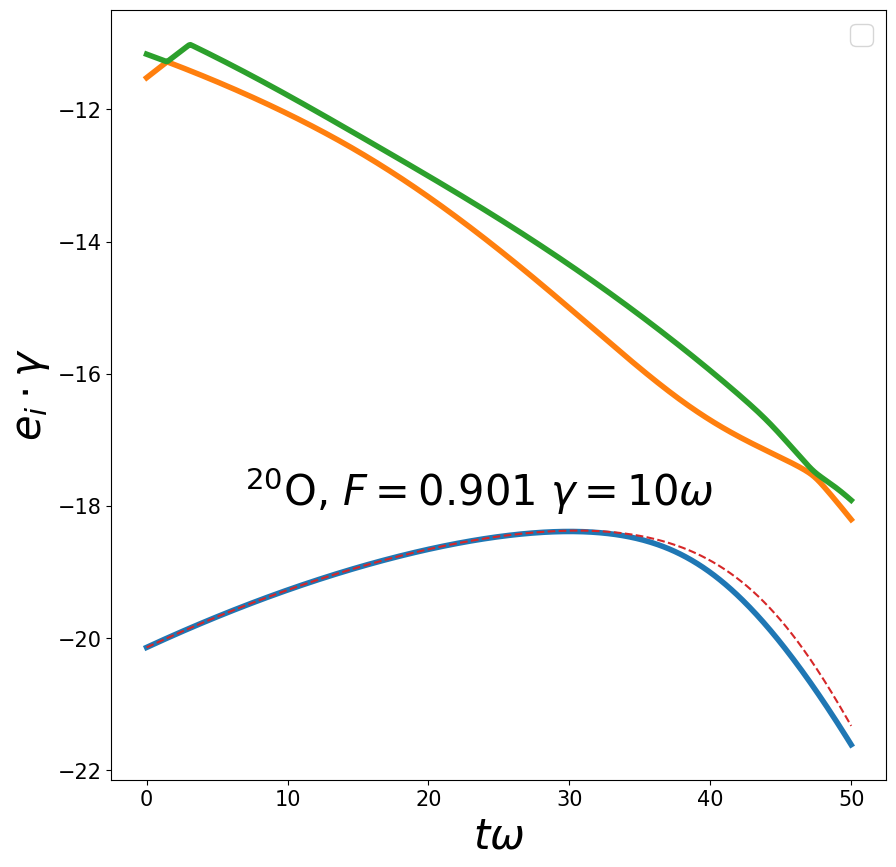

-21.32543057711461


In [83]:
plt.figure(figsize=(10, 10))
plt.plot(time, spectrum * gamma, linewidth=4)
plt.plot(time, energy * gamma, linestyle="--")
psi_qutip = array_to_qutip(psi, n_qubits)
f_value = fidelity(psi_qutip, eigenstates_total_hamiltonian[0])
print(
    "fidelity=",
    fidelity(psi_qutip, eigenstates_total_hamiltonian[0]),
    eigenvalues_total_hamiltonian[0],
)
plt.text(
    x=7,
    y=-1.8 * gamma,
    s=r"$^{20}\text{O}$, $F=$"
    + f"{f_value:.3f} "
    + r"$\gamma=$"
    + f"{gamma:.0f}"
    + r"$\omega$",
    fontsize=30,
)
plt.xlabel(r"$t\omega$", fontsize=30)
plt.ylabel(r"$e_i \cdot \gamma$", fontsize=30)
plt.legend(fontsize=20)
plt.tick_params(which="major", labelsize=15)

plt.show()

print(energy[-1] * gamma)

#### Robstness of the Gadget vs $\gamma$

We study the robustness of the Gadget Hamiltonian tuning the $\gamma$ parameter, to check if we can reduce it to comparable values

In [84]:
from qutip import fidelity

gammas = np.linspace(1, 200, 40)
energy_error = []
fidelities = []
for gamma in gammas:
    # get the total particle constrain
    ntot = 2  # here ntot is different from 1
    # we define the effective longitudianl field that contributes to the NSM quasiparticle hamiltonian of Be 6
    effective_longitudinal_field = (
        diagonal_elements + 0.5 * (d_opt**2).sum() / ntot
    ) / (gamma)

    # lets start with the Z_A Z_B of the constrain
    hamiltonian_zz = 0.0
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            hamiltonian_zz += SpinOperator(
                [("qz", i, "qz", j)],
                coupling=[2 * gamma + g_twobody[(i, j)] / gamma],
                size=n_qubits,
                verbose=1,
            ).qutip_op

    # then the linear terms
    hamiltonian_z = 0.0
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        hamiltonian_z += SpinOperator(
            [("qz", i)],
            coupling=[effective_longitudinal_field[i] + gamma * (1 - 2 * ntot)],
            size=n_qubits,
            verbose=1,
        ).qutip_op

    # finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
    identity_qubit_space = qt.tensor([qt.qeye(2)] * n_qubits)

    longitudinal_hamiltonian = (
        hamiltonian_zz + hamiltonian_z + gamma * (ntot**2) * identity_qubit_space
    )

    # the transverse field is part of the variable hamiltonian
    transverse_hamiltonian = 0.0
    for i in range(n_qubits):
        transverse_hamiltonian += SpinOperator(
            [("x", i)], coupling=[d_opt[i] / np.sqrt(2)], size=n_qubits, verbose=1
        ).qutip_op

    total_hamiltonian = longitudinal_hamiltonian + transverse_hamiltonian

    eigenvalues_total_hamiltonian, eigenstates_total_hamiltonian = (
        total_hamiltonian.eigenstates()
    )
    print(
        eigenvalues_total_hamiltonian[0] * gamma,
        value[0],
    )
    energy_error.append(
        np.abs(eigenvalues_total_hamiltonian[0] * gamma - value[0]) / np.abs(value[0])
    )
    print(
        "fidelities=",
        qt.fidelity(eigenstates_total_hamiltonian[0], eigenstates_nsm[gs_idx]),
        "\n",
    )
    fidelities.append(
        qt.fidelity(eigenstates_total_hamiltonian[0], eigenstates_nsm[gs_idx])
    )

-31.509038082503867 -23.424939176438905
fidelities= 0.02023015135787764 

-22.605750021214163 -23.424939176438905
fidelities= 0.920489573232036 

-23.134379122370607 -23.424939176438905
fidelities= 0.9701750600856343 

-23.33895810264565 -23.424939176438905
fidelities= 0.9839078719226111 

-23.428377169020404 -23.424939176438905
fidelities= 0.9895993846768858 

-23.47420823725958 -23.424939176438905
fidelities= 0.9924652820208812 

-23.50056074068776 -23.424939176438905
fidelities= 0.9940998673420424 

-23.517027341283033 -23.424939176438905
fidelities= 0.9951167703049487 

-23.527976618793556 -23.424939176438905
fidelities= 0.9957911468552536 

-23.535615045717517 -23.424939176438905
fidelities= 0.9962607846482114 

-23.541150426731864 -23.424939176438905
fidelities= 0.9966007093143125 

-23.5452875430383 -23.424939176438905
fidelities= 0.9968545463854398 

-23.548459540688953 -23.424939176438905
fidelities= 0.9970490413928315 

-23.550944280326696 -23.424939176438905
fidelities= 0.99

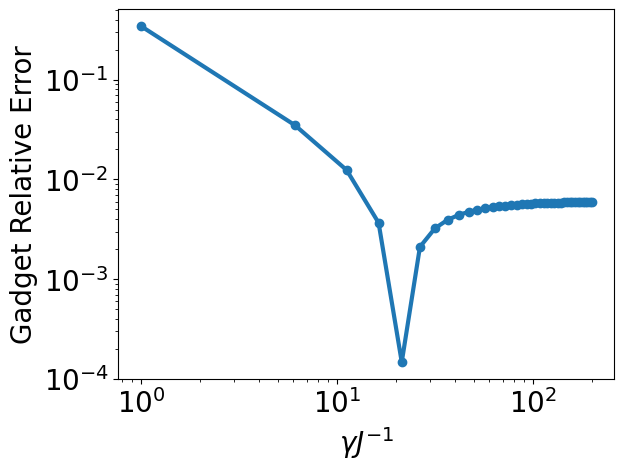

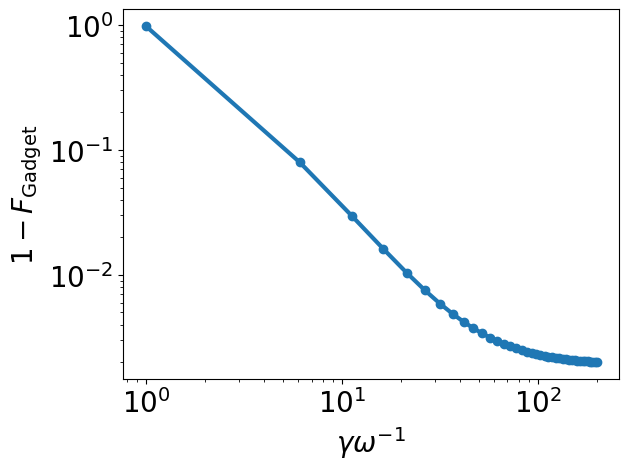

In [85]:
plt.plot(gammas, energy_error, linewidth=3, marker="o")
plt.xlabel(r"$\gamma J^{-1}$", fontsize=20)
plt.ylabel("Gadget Relative Error", fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()

plt.plot(gammas, 1 - np.array(fidelities), linewidth=3, marker="o")
plt.xlabel(r"$\gamma \omega^{-1}$", fontsize=20)
plt.ylabel(r"$1-F_{\text{Gadget}}$", fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()

#### What about the state preparation using QA then ??

In [88]:
import scipy.sparse as sp
from scipy.sparse.linalg import expm_multiply

fidelities = []
energy_error = []
gammas = np.linspace(1, 50, 10)
for gamma in gammas:
    # get the total particle constrain
    ntot = 2
    identity_qubit_space = qt.tensor([qt.qeye(2)] * n_qubits)

    #### total Hamiltonian at this gamma (same construction as the gamma=10 cell above)
    effective_longitudinal_field = (
        diagonal_elements + 0.5 * (d_opt**2).sum() / ntot
    ) / (gamma)

    hamiltonian_zz = 0.0
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            hamiltonian_zz += SpinOperator(
                [("qz", i, "qz", j)],
                coupling=[2 * gamma + g_twobody[(i, j)] / gamma],
                size=n_qubits,
                verbose=1,
            ).qutip_op

    hamiltonian_z = 0.0
    for i in range(n_qubits):
        hamiltonian_z += SpinOperator(
            [("qz", i)],
            coupling=[effective_longitudinal_field[i] + gamma * (1 - 2 * ntot)],
            size=n_qubits,
            verbose=1,
        ).qutip_op

    total_hamiltonian = (
        hamiltonian_zz + hamiltonian_z + gamma * (ntot**2) * identity_qubit_space
    )
    for i in range(n_qubits):
        total_hamiltonian += SpinOperator(
            [("x", i)], coupling=[d_opt[i] / (np.sqrt(2))], size=n_qubits, verbose=1
        ).qutip_op

    #### driver Hamiltonian at this gamma (same construction as the driver cell above)
    external_field = np.zeros(diagonal_elements.shape[0])
    external_field[0] = diagonal_elements[0]
    external_field[1] = diagonal_elements[1]
    effective_longitudinal_field_driver = external_field / gamma

    hamiltonian_zz_driver = 0.0
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            hamiltonian_zz_driver += SpinOperator(
                [("qz", i, "qz", j)],
                coupling=[2 * gamma + g_twobody[(i, j)] / gamma],
                size=n_qubits,
                verbose=1,
            ).qutip_op

    hamiltonian_z_driver = 0.0
    for i in range(n_qubits):
        hamiltonian_z_driver += SpinOperator(
            [("qz", i)],
            coupling=[effective_longitudinal_field_driver[i] + gamma * (1 - 2 * ntot)],
            size=n_qubits,
            verbose=1,
        ).qutip_op

    driver_hamiltonian = (
        hamiltonian_zz_driver
        + hamiltonian_z_driver
        + gamma * (ntot**2) * identity_qubit_space
    )

    idx_init = np.argsort(driver_hamiltonian.full().diagonal())[0]

    #### Initialize the state and convert the hamiltonians
    total_hamiltonian_sparse = total_hamiltonian.data.as_scipy()
    driver_hamiltonian_sparse = driver_hamiltonian.data.as_scipy()
    psi = np.zeros(basis.shape[0], dtype=complex)
    psi[idx_init] = 1.0

    #### start the time evolution
    tau = 20 * gamma
    time_steps = int(10 * tau)
    time = np.linspace(0, tau, time_steps)
    delta_t = time[1] - time[0]
    for t in time:
        hamiltonian_t_sparse = (1 - t / tau) * driver_hamiltonian_sparse + (
            t / tau
        ) * total_hamiltonian_sparse
        psi = expm_multiply(-1j * delta_t * hamiltonian_t_sparse, psi)

    eigenvalues_total_hamiltonian, eigenstates_total_hamiltonian = (
        total_hamiltonian.eigenstates()
    )
    psi_qutip = array_to_qutip(psi, n_qubits)
    f_value = fidelity(psi_qutip, eigenstates_nsm[gs_idx])
    fidelities.append(f_value)
    energy_error.append(
        np.abs(eigenvalues_total_hamiltonian[0] * gamma - value[0]) / np.abs(value[0])
    )
    print(f"gamma={gamma:.2f}  fidelity={f_value:.4f}")

gamma=1.00  fidelity=0.0161
gamma=6.44  fidelity=0.9270
gamma=11.89  fidelity=0.9728
gamma=17.33  fidelity=0.9853
gamma=22.78  fidelity=0.9904
gamma=28.22  fidelity=0.9930
gamma=33.67  fidelity=0.9944
gamma=39.11  fidelity=0.9953
gamma=44.56  fidelity=0.9959
gamma=50.00  fidelity=0.9963


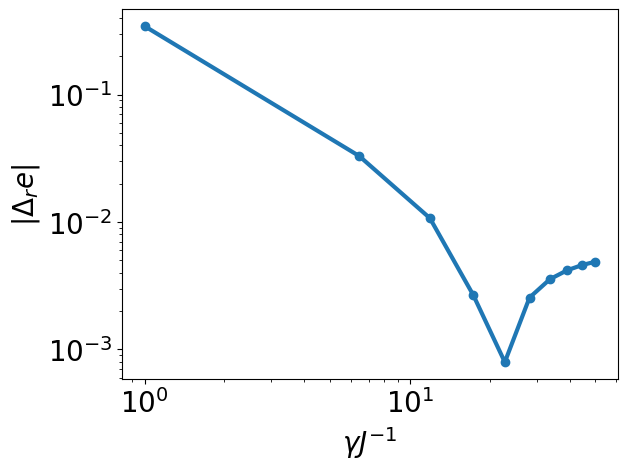

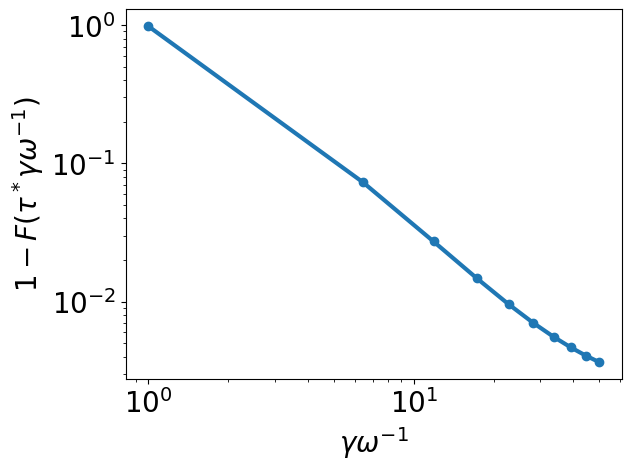

In [92]:
plt.plot(gammas, energy_error, linewidth=3, marker="o")
plt.xlabel(r"$\gamma J^{-1}$", fontsize=20)
plt.ylabel(r"$|\Delta_r e|$", fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()

plt.plot(gammas, 1 - np.array(fidelities), linewidth=3, marker="o")
plt.xlabel(r"$\gamma \omega^{-1}$", fontsize=20)
plt.ylabel(r"$1-F(\tau^* \gamma \omega^{-1} )$", fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()